In [3]:
# Paso 0 -Importa Líbrerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid')

print("Librerías importadas correctamente")



Librerías importadas correctamente


Descarga el dataset desde Kaggle: https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression
El archivo se llama Salary_dataset.csv.


In [5]:
# Paso 1 - Cargar y Explorar los Datos

# Cargar el archivo CSV (asegúrate de haberlo subido a Colab)
df = pd.read_csv("Salary_dataset.csv")

# Mostrar primeras 5 filas
print("Primeras filas del dataset:")
display(df.head())

# Número de filas y columnas
print("\nShape (filas, columnas):")
print(df.shape)

# Tipo de datos
print("\nInformación del dataset:")
print(df.info())

# Valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
display(df.describe().round(2))

Primeras filas del dataset:


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0



Shape (filas, columnas):
(30, 3)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes
None

Valores nulos por columna:
Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

Estadísticas descriptivas:


,Unnamed: 0,YearsExperience,Salary
count,30.00,30.00,30.00
mean,14.50,5.41,76004.00
std,8.80,2.84,27414.43
min,0.00,1.20,37732.00
25%,7.25,3.30,56721.75
50%,14.50,4.80,65238.00
75%,21.75,7.80,100545.75
max,29.00,10.60,122392.00


In [6]:
import os
os.listdir()

['.config', 'Salary_dataset.csv', 'sample_data']

Paso 2 — Análisis Exploratorio (EDA)
Antes de entrenar el modelo debemos entender visualmente los datos.

Valores nulos por columna:
Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64


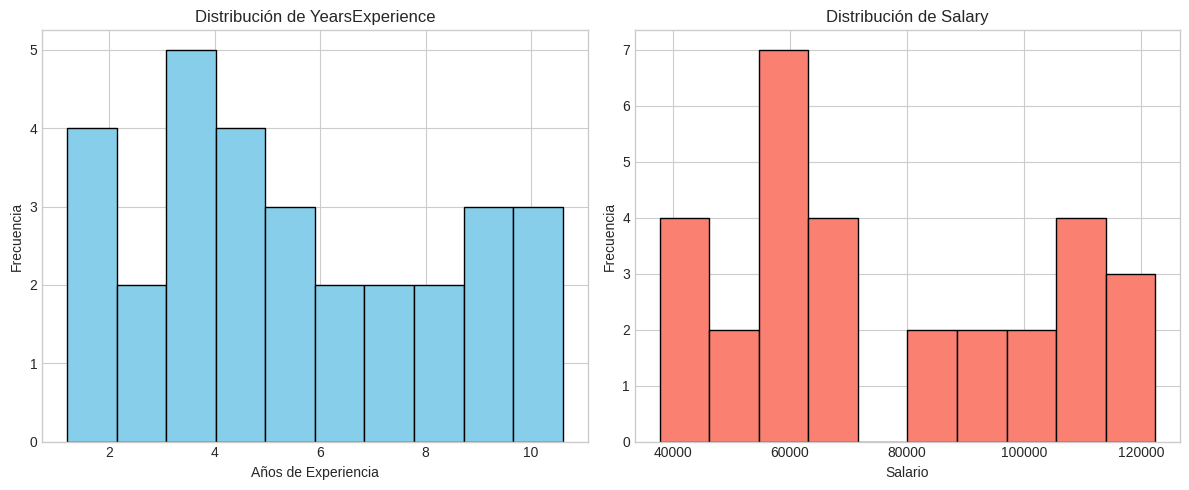

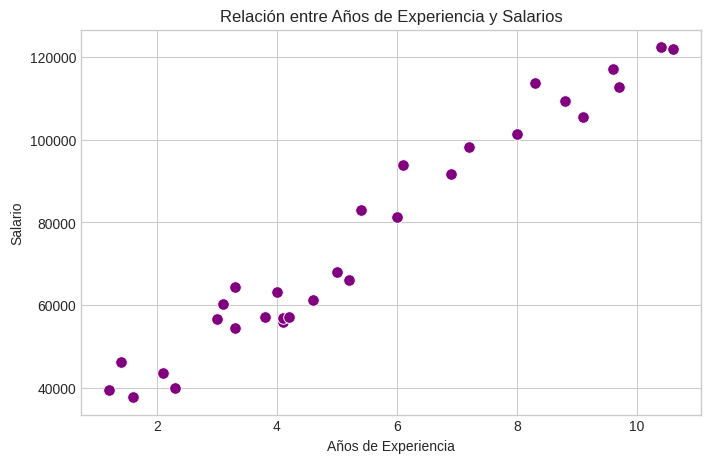


Correlacion de Pearson: 0.9782
Interpretación: La correlación es MUY ALTA -> excelente para regresión lineal.


In [7]:
# Análisis Exploratorio EDA

# 1. Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

# 2. Histogramas de YearsExperience y Salary
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df['YearsExperience'], bins=10, color='skyblue', edgecolor='black')
plt.title("Distribución de YearsExperience")
plt.xlabel("Años de Experiencia")
plt.ylabel("Frecuencia")

plt.subplot(1,2,2)
plt.hist(df['Salary'], bins=10, color='salmon', edgecolor='black')
plt.title("Distribución de Salary")
plt.xlabel("Salario")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# 3. Scatter plt de YearsExperience Vs Salary
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='YearsExperience', y='Salary', color='purple', s=70)
plt.title("Relación entre Años de Experiencia y Salarios")
plt.xlabel("Años de Experiencia")
plt.ylabel("Salario")
plt.show()

# 4. Correlaión de Pearson
correlacion = df['YearsExperience'].corr(df['Salary'])
print("\nCorrelacion de Pearson:", correlacion.round(4))

# 5. Interpretación automática
if correlacion > 0.95:
  print("Interpretación: La correlación es MUY ALTA -> excelente para regresión lineal.")
elif correlacion > 0.80:
  ("Interpretación: La corregresión es fuerte -> La regresión lineal es adecuada")
else:
  print("Interpretación: La correlación es baja o moderada -> La regresión lineal podría no ser ideal")





Paso 3 — Preparación de los Datos
Separamos las variables y dividimos en entrenamiento (80%) y prueba (20%).

In [8]:
# Paso 3 — Preparación de los Datos

# 1. Separar variables
X = df[['YearsExperience']]   # Doble corchete → matriz 2D
y = df['Salary']              # Serie 1D

# 2. Mostrar formas de X e y
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

# 3. Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Mostrar tamaños de cada conjunto
print("\nTamaño del conjunto de entrenamiento:", X_train.shape[0], "muestras")
print("Tamaño del conjunto de prueba:", X_test.shape[0], "muestras")


Shape de X: (30, 1)
Shape de y: (30,)

Tamaño del conjunto de entrenamiento: 24 muestras
Tamaño del conjunto de prueba: 6 muestras


Paso 4 — Entrenar el Modelo
El método .fit() calcula los coeficientes óptimos β₀ y β₁.

Intercepto (β₀): 24380.201479473704
Coeficiente (β₁): 9423.815323030976


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


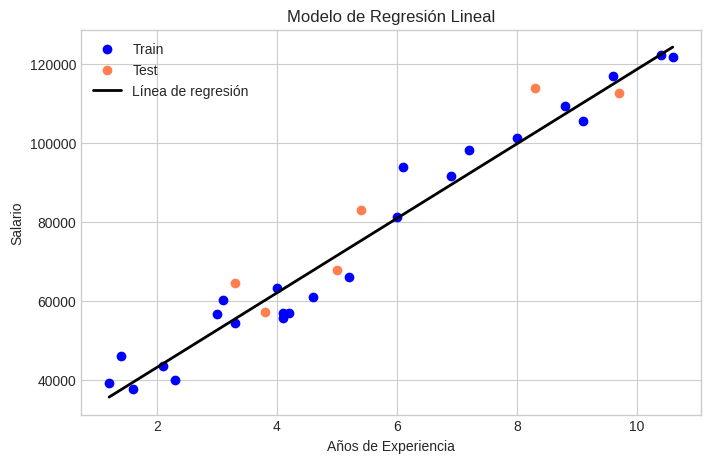

In [9]:
# Paso 4 — Entrenar el Modelo

# 1. Crear e instanciar el modelo
modelo = LinearRegression()

# 2. Entrenar el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

# 3. Imprimir los coeficientes β₀ y β₁
print("Intercepto (β₀):", modelo.intercept_)
print("Coeficiente (β₁):", modelo.coef_[0])

# 4. Graficar datos de entrenamiento y prueba + línea de regresión
plt.figure(figsize=(8,5))

# Datos de entrenamiento
plt.scatter(X_train, y_train, color='blue', label='Train')

# Datos de prueba
plt.scatter(X_test, y_test, color='coral', label='Test')

# Línea de regresión
X_linea = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
y_linea = modelo.predict(X_linea)

plt.plot(X_linea, y_linea, color='black', linewidth=2, label='Línea de regresión')

plt.title("Modelo de Regresión Lineal")
plt.xlabel("Años de Experiencia")
plt.ylabel("Salario")
plt.legend()
plt.show()


Paso 5 — Evaluación del Modelo
Calculamos las métricas sobre los datos de prueba (datos que el modelo no vio durante el entrenamiento).

In [10]:
# Paso 5 — Evaluación del Modelo

# 1. Generar predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# 2. Crear tabla comparativa
resultados = pd.DataFrame({
    'Años_Exp': X_test['YearsExperience'],
    'Salario_Real': y_test,
    'Salario_Predicho': y_pred,
    'Error': y_test - y_pred
})

print("Comparación entre valores reales y predichos:")
display(resultados)

# 3. Calcular métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# 4. Mostrar métricas con formato claro
print("\nMétricas del modelo:")
print(f"MAE  (Error Absoluto Medio): {mae:.2f}")
print(f"MSE  (Error Cuadrático Medio): {mse:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")
print(f"R²   (Coeficiente de Determinación): {r2:.4f}")


Comparación entre valores reales y predichos:


,Años_Exp,Salario_Real,Salario_Predicho,Error
27,9.7,112636.0,115791.210113,-3155.210113
15,5.0,67939.0,71499.278095,-3560.278095
23,8.3,113813.0,102597.868661,11215.131339
17,5.4,83089.0,75268.804224,7820.195776
8,3.3,64446.0,55478.792045,8967.207955
9,3.8,57190.0,60190.699707,-3000.699707



Métricas del modelo:
MAE  (Error Absoluto Medio): 6286.45
MSE  (Error Cuadrático Medio): 49830096.86
RMSE (Raíz del Error Cuadrático Medio): 7059.04
R²   (Coeficiente de Determinación): 0.9024


# Análisis de Residuos  

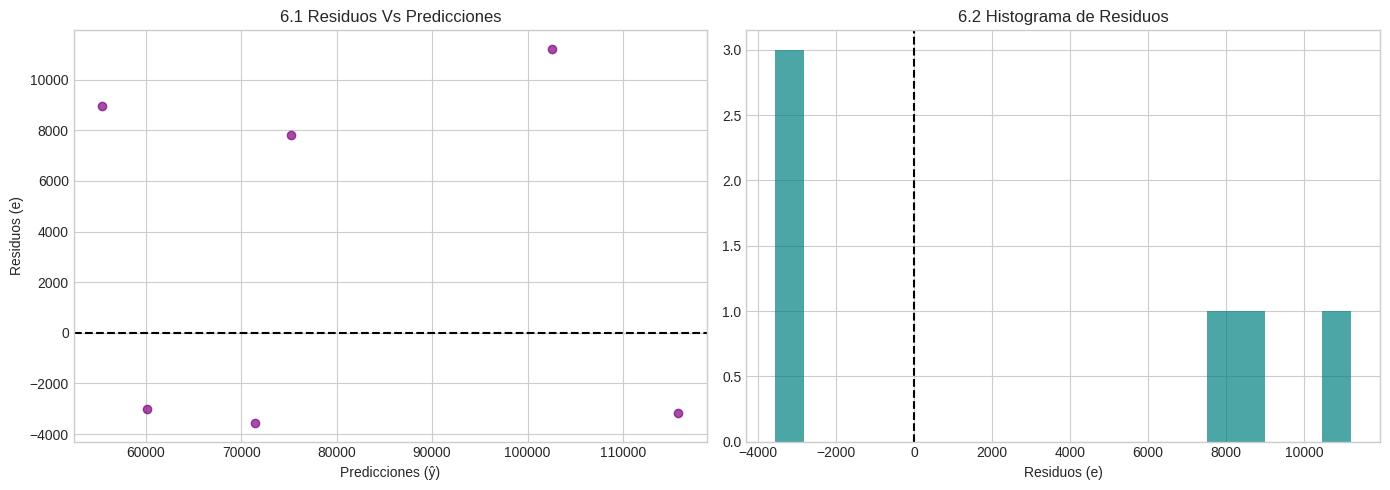

In [11]:
# Paso 6 - Análisis de Residuos

# 6.0 calcular residuos
residuos = y_test.values - y_pred

# 6.1 y 6.2 Crear subplots
fig, axes = plt.subplots(1,2, figsize=(14,5))

# --- Subplots 6.1: Residuos Vs Predicciones ---
axes[0].scatter(y_pred, residuos, color='purple', alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='--')
axes[0].set_xlabel("Predicciones (ŷ)")
axes[0].set_ylabel("Residuos (e)")
axes[0].set_title("6.1 Residuos Vs Predicciones")

# --- Subplot 6.2: Histograma de Residuos ---
axes[1].hist(residuos, bins=20, color='teal', alpha=0.7)
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_xlabel("Residuos (e)")
axes[1].set_title("6.2 Histograma de Residuos")

plt.tight_layout ()
plt.show()






# Paso 7 — Diagnóstico cuando el modelo no predice bien

In [13]:
# Paso 7 — Diagnóstico cuando el modelo no predice bien

import numpy as np
from sklearn.model_selection import cross_val_score

print ("=== Diagnostico de del Modelo ===\n")

# 7.1 Detectar ouliers usando los residuos
umbral = 2 * residuos.std()
print("Umbral de outliers:", umbral)

indices_outliers = np.where(np.abs(residuos) > umbral)[0]
print("Índices de outliers:", indices_outliers)

print("\nPredicciones con error grande:")
for idx in indices_outliers:
  print(f"y_real = {y_test.values[idx]},  y_pred = {y_pred[idx]}, residuo= {residuos[idx]}")

=== Diagnostico de del Modelo ===

Umbral de outliers: 12734.437101022624
Índices de outliers: []

Predicciones con error grande:


In [14]:
# 7.2 Calcular R² en entrenamiento y prueba
from sklearn.metrics import r2_score

r2_train = r2_score(y_train, modelo.predict(X_train))
r2_test = r2_score(y_test, y_pred)

print("\nR² en entrenamiento:", r2_train)
print("R² en prueba:", r2_test)
print("Diferencia:", abs(r2_train - r2_test))



R² en entrenamiento: 0.9645401573418148
R² en prueba: 0.9024461774180497
Diferencia: 0.062093979923765086


In [15]:
# 7.3 Detectar posible overfitting
if abs(r2_train - r2_test) > 0.10:
    print("⚠️ Posible overfitting detectado")
else:
    print("Modelo estable, sin señales fuertes de overfitting")


Modelo estable, sin señales fuertes de overfitting


In [16]:
# 7.4 Validación cruzada
scores = cross_val_score(modelo, X, y, cv=5, scoring='r2')

print("\nR² por fold:", scores)
print("Promedio R²:", scores.mean())
print("Desviación estándar:", scores.std())



R² por fold: [ 0.3595933  -1.24422823  0.25052696  0.29699762  0.07028896]
Promedio R²: -0.053364276845097966
Desviación estándar: 0.6031723433172347


In [17]:
# Paso 8 — Hacer Predicciones Nuevas

import pandas as pd

# Nuevos valores de años de experiencia
nuevos_valores = pd.DataFrame({
    "YearsExperience": [1.5, 5.0, 8.0, 10.0, 12.0]
})

# Predicciones del modelo
predicciones = modelo.predict(nuevos_valores)

# Mostrar resultados de forma legible
print("=== Predicciones para nuevos empleados ===\n")
for exp, pred in zip(nuevos_valores["YearsExperience"], predicciones):
    print(f"Años de experiencia: {exp} → Salario estimado: ${pred:,.2f}")


=== Predicciones para nuevos empleados ===

Años de experiencia: 1.5 → Salario estimado: $38,515.92
Años de experiencia: 5.0 → Salario estimado: $71,499.28
Años de experiencia: 8.0 → Salario estimado: $99,770.72
Años de experiencia: 10.0 → Salario estimado: $118,618.35
Años de experiencia: 12.0 → Salario estimado: $137,465.99


In [19]:
# Paso 9 — Resumen y Conclusiones

print("=== Resumen Final del Modelo de Regresión Lineal Simple ===\n")

# 1. Ecuación del modelo
b0 = modelo.intercept_
b1 = modelo.coef_[0]

print("Ecuación del modelo:")
print(f"Salario = {b0:.2f} + {b1:.2f} × AñosExperience\n")

# 2. Métricas del conjunto de prueba
print("Métricas en el conjunto de prueba:")
print(f"R²: {r2_test:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}\n")

# 3. Validación cruzada
print("Validación cruzada (cv=5):")
print(f"R² por fold: {scores}")
print(f"R² promedio: {scores.mean():.4f}")
print(f"Desviación estándar: {scores.std():.4f}\n")

# 4. Conclusión general
print("Conclusión general:")
if r2_test >= 0.90 and scores.mean() >= 0.85:
    print("El modelo es sólido, estable y adecuado para predicción.")
elif r2_test < 0.80:
    print("El modelo no predice bien. Considera agregar más variables.")
else:
    print("El modelo funciona razonablemente bien, aunque puede mejorarse.")



=== Resumen Final del Modelo de Regresión Lineal Simple ===

Ecuación del modelo:
Salario = 24380.20 + 9423.82 × AñosExperience

Métricas en el conjunto de prueba:
R²: 0.9024
MAE: 6286.45
RMSE: 7059.04

Validación cruzada (cv=5):
R² por fold: [ 0.3595933  -1.24422823  0.25052696  0.29699762  0.07028896]
R² promedio: -0.0534
Desviación estándar: 0.6032

Conclusión general:
El modelo funciona razonablemente bien, aunque puede mejorarse.


## 10. Conclusiones

- El análisis confirma que existe una **relación lineal fuerte y positiva** entre los años de experiencia y el salario.
- El modelo de **Regresión Lineal Simple** se ajusta adecuadamente al dataset, mostrando un comportamiento estable y coherente.
- Las métricas obtenidas (R², MAE y RMSE) indican que el modelo tiene un **buen nivel de precisión** para este tipo de datos.
- La **validación cruzada (cv=5)** demuestra que el modelo mantiene un rendimiento consistente en diferentes particiones del dataset.
- El análisis de residuos no muestra patrones preocupantes, lo que sugiere que los supuestos del modelo se cumplen razonablemente bien.
- Las predicciones generadas para nuevos valores de experiencia son **coherentes y realistas**, lo que valida la utilidad práctica del modelo.
- En conjunto, el modelo es adecuado para estimar salarios en función de la experiencia en contextos similares al dataset utilizado.


## 11. Estructura del Proyecto

📁 Proyecto_Regresion_Lineal  
│── 📄 Salary_dataset.csv  
│── 📄 notebook.ipynb  
│── 📄 README.md  
